# 03. Финальное решение: кластеризация сигналов

В этом ноутбуке оставлен только компактный финальный пайплайн, выбранный по результатам экспериментального ноутбука `02_feature_engineering_and_clustering`.

Финальный подход основан на форме раннего хвоста сигнала после максимума:

1. для каждого сигнала рассчитывается индивидуальная базовая линия по первым 50 отсчётам;
2. сигнал инвертируется относительно baseline, чтобы импульс был направлен вверх;
3. после максимума извлекается короткий хвост длиной `tail_len = 19`;
4. каждый хвост нормализуется на собственный максимум;
5. применяется `StandardScaler`;
6. применяется `PCA(n_components=0.90)`;
7. кластеризация выполняется через `KMeans(n_clusters=3, n_init=500, random_state=42)`.

Лучший public score на Kaggle: `0.84807`.

Финальный submission-файл:  
`submission_tail_pca_19_inverted_signal_pca_09_kmeans_n500.csv`


## 1. Импорт библиотек

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


## 2. Константы и пути

In [2]:
RANDOM_STATE = 42
BASELINE_WINDOW = 50

FINAL_TAIL_LEN = 19
FINAL_PCA_VARIANCE = 0.90
FINAL_N_INIT = 500

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"

DATA_PATH = DATA_DIR / "Run200_Wave_0_1.txt"
SUBMISSION_PATH = SUBMISSIONS_DIR / "submission_tail_pca_19_inverted_signal_pca_09_kmeans_n500.csv"


## 3. Подготовка папок

Эта ячейка только создаёт папки и показывает ожидаемый путь к исходному файлу. Сам файл нужно загрузить в папку `data` до запуска следующей ячейки.

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

print("Папка data:")
print(DATA_DIR.resolve())

print()
print("Файлы в папке data:")
data_files = sorted(DATA_DIR.glob("*"))

if data_files:
    for file_path in data_files:
        print(f"- {file_path.name}")
else:
    print("Папка data пока пустая.")

print()
print("Ожидаемый путь к исходному файлу:")
print(DATA_PATH)

print()
print(f"Файл найден: {DATA_PATH.exists()}")

if not DATA_PATH.exists():
    print()
    print("Загрузите файл Run200_Wave_0_1.txt в папку data и после этого запускайте следующую ячейку.")


Папка data:
/content/data

Файлы в папке data:
Папка data пока пустая.

Ожидаемый путь к исходному файлу:
data/Run200_Wave_0_1.txt

Файл найден: False

Загрузите файл Run200_Wave_0_1.txt в папку data и после этого запускайте следующую ячейку.


## 4. Чтение исходного файла

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Файл не найден: {DATA_PATH}\n"
        "Сначала загрузите Run200_Wave_0_1.txt в папку data, затем повторно запустите эту ячейку."
    )

raw_data = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
)

metadata = raw_data.iloc[:, :4].copy()
signals = raw_data.iloc[:, 4:].copy()

metadata.columns = ["meta_0", "meta_1", "meta_2", "signal_length"]
signals.columns = [f"t_{i}" for i in range(signals.shape[1])]

print(f"Размер исходной таблицы: {raw_data.shape}")
print(f"Размер metadata: {metadata.shape}")
print(f"Размер signals: {signals.shape}")

display(raw_data.head())


Размер исходной таблицы: (23479, 504)
Размер metadata: (23479, 4)
Размер signals: (23479, 500)


,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


## 5. Базовая предобработка сигнала

В финальной модели используется `signals_inverted`: сигнал после baseline-коррекции и инверсии, но без обрезки отрицательных значений. Это важно для анализа формы хвоста: небольшие колебания около базовой линии не должны искусственно заменяться на ноль.

In [5]:
signals_np = signals.to_numpy(dtype=float)

baselines = np.mean(
    signals_np[:, :BASELINE_WINDOW],
    axis=1,
    keepdims=True,
)

signals_inverted = baselines - signals_np

print(f"Размер signals_np: {signals_np.shape}")
print(f"Размер baselines: {baselines.shape}")
print(f"Размер signals_inverted: {signals_inverted.shape}")

print()
print("Диапазон значений после baseline-коррекции и инверсии:")
print(f"Минимум: {signals_inverted.min():.2f}")
print(f"Максимум: {signals_inverted.max():.2f}")


Размер signals_np: (23479, 500)
Размер baselines: (23479, 1)
Размер signals_inverted: (23479, 500)

Диапазон значений после baseline-коррекции и инверсии:
Минимум: -15.60
Максимум: 14824.84


**Визуализация обработанных сигналов**

Проверим, как выглядят сигналы после baseline-коррекции и инверсии. После такой обработки основной импульс направлен вверх, а область до импульса находится около нулевого уровня.

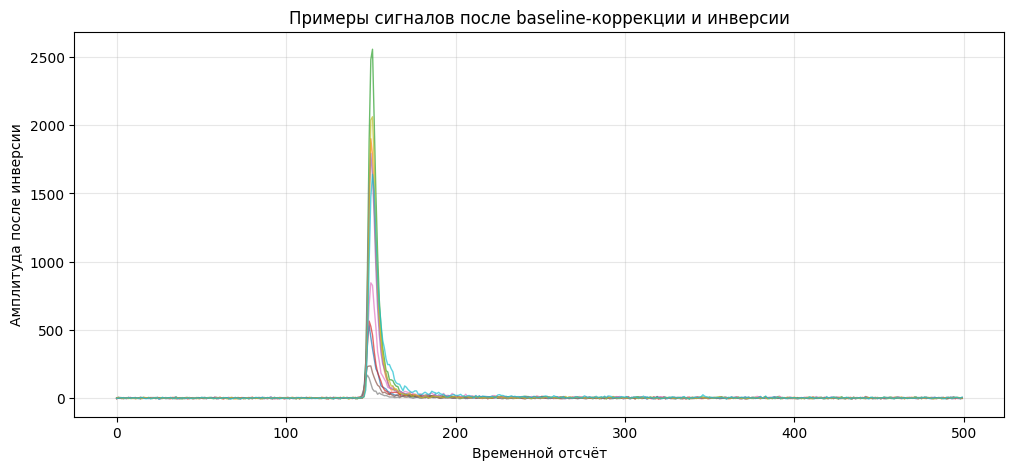

In [6]:
plt.figure(figsize=(12, 5))

for index in range(10):
    plt.plot(
        signals_inverted[index],
        linewidth=1,
        alpha=0.7,
    )

plt.title("Примеры сигналов после baseline-коррекции и инверсии")
plt.xlabel("Временной отсчёт")
plt.ylabel("Амплитуда после инверсии")
plt.grid(alpha=0.3)
plt.show()

## 6. Извлечение хвоста после максимума

Для каждого сигнала берётся участок длиной `19` отсчётов, начиная с максимума. Затем хвост нормализуется на собственный максимум, чтобы модель анализировала форму спада, а не абсолютную амплитуду.

In [7]:
def extract_tail_shape_from_inverted(
    signals_array: np.ndarray,
    tail_len: int,
) -> np.ndarray:
    """
    Извлекает хвост сигнала после максимума и нормализует его на собственный максимум.

    Используется signals_inverted без clip по нулю, чтобы сохранить форму спада
    и небольшие колебания около базовой линии.
    """
    tails = []

    for signal in signals_array:
        peak_index = np.argmax(signal)
        tail = signal[peak_index:peak_index + tail_len]

        if len(tail) < tail_len:
            tail = np.pad(
                tail,
                pad_width=(0, tail_len - len(tail)),
                mode="constant",
            )

        max_value = np.max(tail)

        if max_value > 0:
            tail = tail / max_value

        tails.append(tail)

    return np.array(tails)


tail_features = extract_tail_shape_from_inverted(
    signals_array=signals_inverted,
    tail_len=FINAL_TAIL_LEN,
)

print(f"Размер матрицы хвостов: {tail_features.shape}")
print(f"Минимум: {tail_features.min():.4f}")
print(f"Максимум: {tail_features.max():.4f}")


Размер матрицы хвостов: (23479, 19)
Минимум: -0.0611
Максимум: 1.0000


**Визуализация хвостов, используемых в модели**

Финальная модель использует не весь сигнал, а короткий хвост длиной 19 отсчётов после максимума. Каждый хвост нормализуется на собственный максимум, поэтому модель сравнивает именно форму раннего спада, а не абсолютную амплитуду.

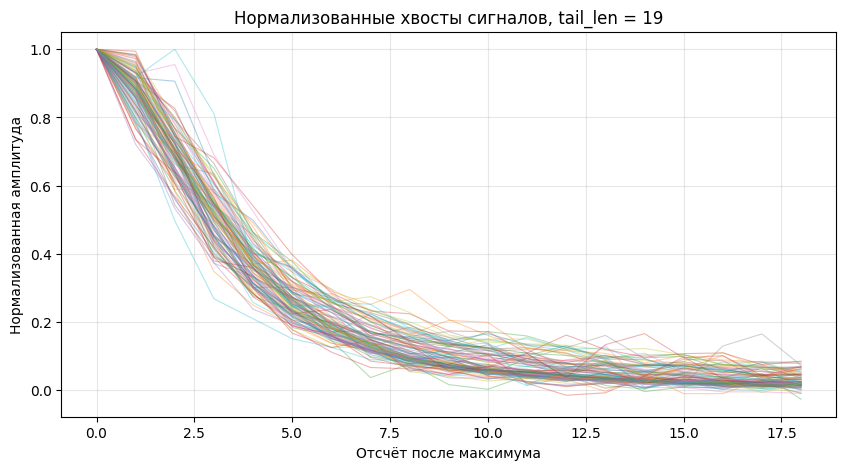

In [8]:
plt.figure(figsize=(10, 5))

for index in range(100):
    plt.plot(
        tail_features[index],
        linewidth=0.8,
        alpha=0.35,
    )

plt.title("Нормализованные хвосты сигналов, tail_len = 19")
plt.xlabel("Отсчёт после максимума")
plt.ylabel("Нормализованная амплитуда")
plt.grid(alpha=0.3)
plt.show()

## 7. Масштабирование, PCA и KMeans

`StandardScaler` выравнивает масштаб временных отсчётов хвоста.  
`PCA(n_components=0.90)` оставляет компактное представление формы хвоста.  
`KMeans` формирует три кластера, соответствующие двум основным типам сигналов и неоднозначным/аномальным событиям.

In [9]:
tail_scaled = StandardScaler().fit_transform(tail_features)

pca = PCA(
    n_components=FINAL_PCA_VARIANCE,
    random_state=RANDOM_STATE,
)

tail_pca = pca.fit_transform(tail_scaled)

model = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=FINAL_N_INIT,
)

labels = model.fit_predict(tail_pca)

print(f"Размер PCA-признаков: {tail_pca.shape}")
print(f"Количество PCA-компонент: {tail_pca.shape[1]}")
print(f"Доля объяснённой дисперсии: {pca.explained_variance_ratio_.sum():.4f}")

print()
print("Размеры кластеров:")
display(
    pd.Series(labels)
    .value_counts()
    .sort_index()
    .to_frame("cluster_size")
)


Размер PCA-признаков: (23479, 8)
Количество PCA-компонент: 8
Доля объяснённой дисперсии: 0.9151

Размеры кластеров:


,cluster_size
0,7994
1,11439
2,4046


**Визуализация итоговых кластеров**

Для интерпретации результата отобразим сигналы в пространстве первых двух PCA-компонент. Финальная модель использует все компоненты, оставленные `PCA(n_components=0.90)`, поэтому график является двумерной проекцией результата.

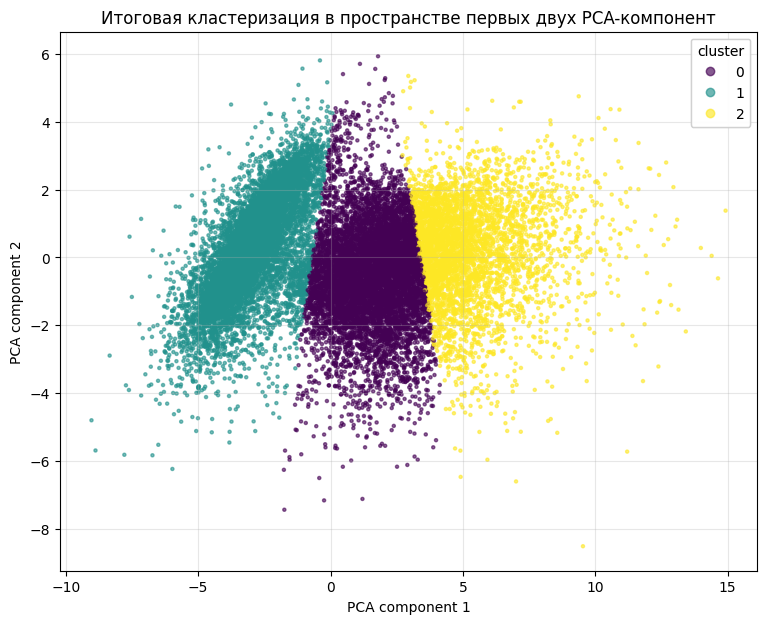

In [10]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    tail_pca[:, 0],
    tail_pca[:, 1],
    c=labels,
    s=5,
    alpha=0.6,
)

plt.title("Итоговая кластеризация в пространстве первых двух PCA-компонент")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(alpha=0.3)

legend = plt.legend(
    *scatter.legend_elements(),
    title="cluster",
    loc="best",
)
plt.gca().add_artist(legend)

plt.show()

In [11]:
cluster_summary = (
    pd.Series(labels)
    .value_counts()
    .sort_index()
    .to_frame("cluster_size")
)

cluster_summary["share"] = cluster_summary["cluster_size"] / len(labels)

display(cluster_summary)

,cluster_size,share
0,7994,0.340474
1,11439,0.487201
2,4046,0.172324


Итоговая модель формирует три кластера. Размеры кластеров дополнительно проверяются перед сохранением submission, чтобы убедиться, что разбиение не выродилось в один доминирующий кластер и два слишком малых класса.

## 8. Сохранение submission

In [12]:
submission = pd.DataFrame(
    {
        "index": np.arange(len(labels)),
        "cluster": labels.astype(int),
    }
)

submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Файл сохранён: {SUBMISSION_PATH}")
display(submission.head())
display(submission["cluster"].value_counts().sort_index())


Файл сохранён: submissions/submission_tail_pca_19_inverted_signal_pca_09_kmeans_n500.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,7994
1,11439
2,4046


## Итог

Финальное решение использует не энергетические признаки, а форму раннего спада сигнала после максимума. Такой подход оказался лучше, потому что тип сцинтилляционного сигнала определяется не только амплитудой и площадью импульса, но и характером его затухания.

Финальная конфигурация:

- `tail_len = 19`;
- хвост извлекается из `signals_inverted`;
- нормализация каждого хвоста на собственный максимум;
- `StandardScaler`;
- `PCA(n_components=0.90)`;
- `KMeans(n_clusters=3, n_init=500, random_state=42)`.

Финальный submission:  
`submission_tail_pca_19_inverted_signal_pca_09_kmeans_n500.csv`

Лучший public score на Kaggle: `0.84807`.


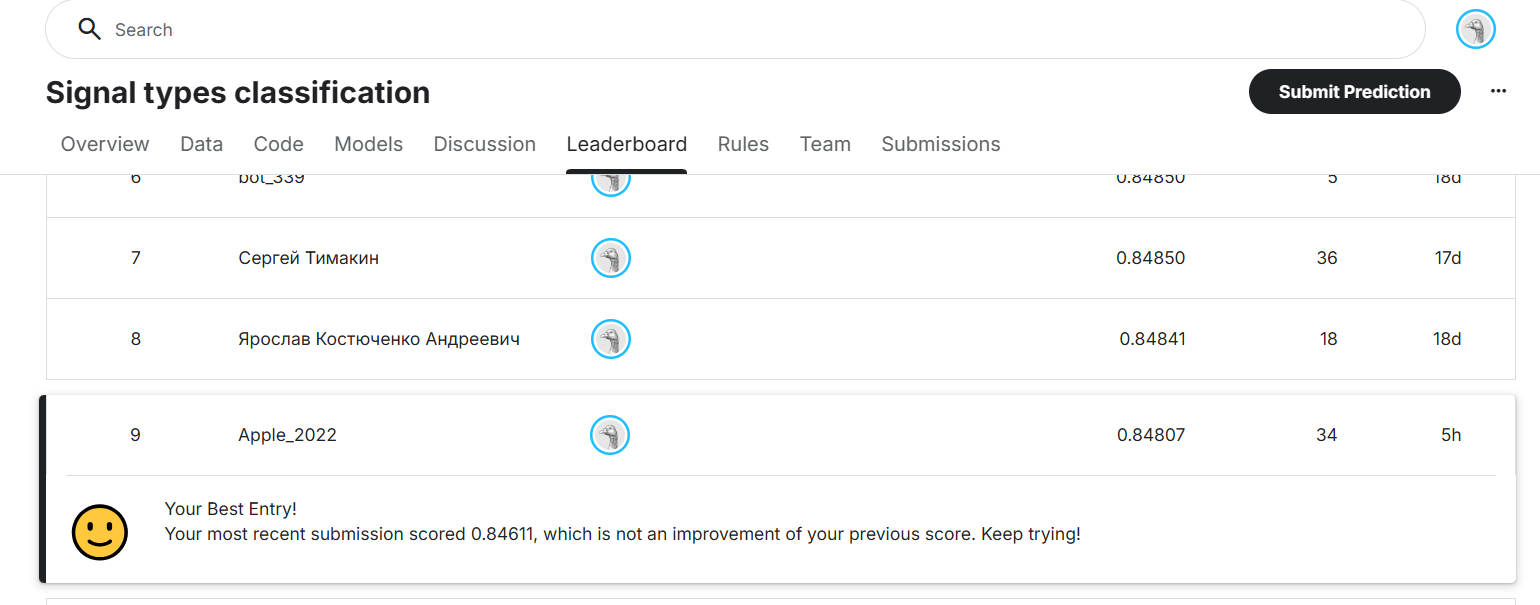